La efectividad de una gráfica depende tanto del diseño como de los datos. Estas guías ayudan a construir visualizaciones claras, consistentes y reproducibles con Matplotlib.

15.1 Principios de diseño visual
Claridad primero: un mensaje por gráfico; si hay varias ideas, separalas en subplots.

Contexto explícito: títulos informativos, ejes con unidades y fuente de datos cuando corresponda.

Orden lógico: ordená categorías por valor, alfabéticamente o cronológicamente.

Jerarquía tipográfica: títulos > etiquetas > ticks > leyenda; evitá textos inclinados.

Color con intención: paleta corta, apta para daltónicos; usá grosor o intensidad para enfatizar.

Data-ink ratio: eliminá adornos, bordes dobles y grillas fuertes; mantené una grilla suave (alpha bajo).

Consistencia visual: misma tipografía, paleta y grosores en todo el informe.

In [6]:
import matplotlib as mpl
from cycler import cycler

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.6,
    "lines.markersize": 4.0,
    "legend.frameon": False,
})
mpl.rcParams["axes.prop_cycle"] = cycler(color=[
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"
])

15.2 Escoger el gráfico adecuado

Objetivo	Datos	Gráfico recomendado	Notas
Tendencia en el tiempo --- Serie temporal --- Línea ---	Compartí ejes cuando compares varias series.
Comparar categorías ---	Categórico + numérico ---	Barras (vertical/horizontal) ---	Ordená por valor; nombres largos → barh.
Distribución (1 variable) ---	Numérico ---	Histograma / KDE ---	Usá mismo binning al comparar grupos.
Resumen por grupos ---	Numérico por categoría ---	Boxplot / Violin ---	Muestra mediana, IQR y outliers.
Relación entre 2 variables ---	Numérico + numérico ---	Dispersión ---	Color/tamaño para tercera variable.
Proporciones ---	Partes de un todo --- Barras apiladas / Pie ---	Pie solo con pocas categorías.
Incertidumbre ---	Estimaciones --- Errorbar / bandas ---	fill_between para intervalos.

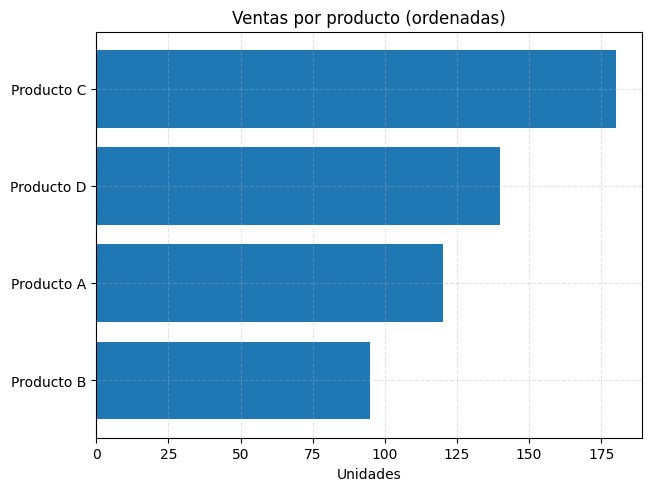

In [5]:
import matplotlib.pyplot as plt

categorias = ["Producto A", "Producto B", "Producto C", "Producto D"]
valores = [120, 95, 180, 140]
orden = sorted(range(len(valores)), key=lambda i: valores[i])
cats_ord = [categorias[i] for i in orden]
vals_ord = [valores[i] for i in orden]

fig, ax = plt.subplots(layout="constrained")
ax.barh(cats_ord, vals_ord)
ax.set_title("Ventas por producto (ordenadas)")
ax.set_xlabel("Unidades")
plt.show()

15.3 Evitar errores comunes
Ejes truncados sin aviso: mostrá el rango completo o anotá claramente el truncado.

Escalas inadecuadas: usá logaritmos para crecimientos multiplicativos e indicá la escala.

Demasiadas series: desglosá en subplots o facetado; etiquetá líneas directamente.

Exceso de colores: preferí paleta corta y consistente; verificá contraste.

3D innecesario: solo si la tercera dimensión aporta información real.

Pie charts con demasiados segmentos: sustituí por barras o barras apiladas.

Doble eje Y confuso: optá por subplots con sharex o normalizá las series.

Binning inconsistente en histogramas: mismo número de bins y rango al comparar grupos.

Ticks ilegibles: reducí cantidad, rotá en 45° o abreviá etiquetas.

No mostrar incertidumbre: agrega bandas, barras de error o anotaciones.

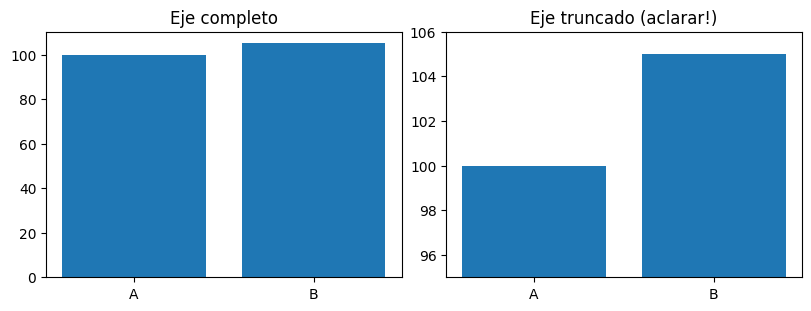

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), layout="constrained")
ax1.bar(["A", "B"], [100, 105])
ax1.set_title("Eje completo")

ax2.bar(["A", "B"], [100, 105])
ax2.set_ylim(95, 106)
ax2.set_title("Eje truncado (aclarar!)")
plt.show()

15.4 Patrones prácticos

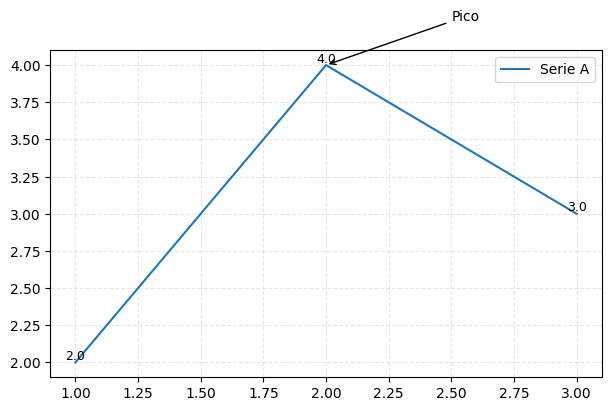

In [3]:
import matplotlib.pyplot as plt

def layout_exportable(fig_path: str):
    fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
    # ... graficar ...
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.plot([1, 2, 3], [2, 4, 3], label="Serie A")
ax.annotate("Pico", xy=(2, 4), xytext=(2.5, 4.3),
            arrowprops={"arrowstyle": "->", "linewidth": 1})
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
for x_val, y_val in zip([1, 2, 3], [2, 4, 3]):
    ax.text(x_val, y_val, f"{y_val:.1f}", va="bottom", ha="center", fontsize=9)
plt.show()

15.5 Checklist final
Propósito claro y un solo mensaje por gráfico.

Ejes con unidades, títulos informativos y fuente de datos si aplica.

Paleta corta, apta para daltónicos; grosor/estilo para reforzar.

Evitá ejes truncados sin aviso, 3D injustificado y doble eje Y confuso.

Comparaciones justas: mismos bins o rangos al comparar grupos.

Mantené consistencia de estilo y exportá con bbox_inches="tight" y DPI adecuados.

Documentá la versión de Matplotlib y las semillas/estilos usados.